# Spatial Branch — Deepfake Detection

## Overview
This branch operates in **pixel space** (not FFT) and detects deepfake manipulations — face swapping, expression reenactment — from facial texture and boundary artifacts.

## Datasets
- **Training + Val + Test:** FaceForensics++ C23 Extracted Faces (pre-split by dataset author)
  - Manipulation types: Deepfakes, Face2Face, FaceShifter, FaceSwap, NeuralTextures, DeepFakeDetection
- **Cross-dataset generalisation test:** CelebDF-v2 (never seen during training)

## Key differences from Frequency Branch
- Input: raw pixels with ImageNet normalisation (NOT FFT)
- Heavier augmentation (geometric + colour jitter)
- Per-manipulation-type tracking in evaluation
- CelebDF cross-dataset eval at end of every run

In [2]:
import os, io, gc, random, csv
from pathlib import Path
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_curve, auc
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [3]:
# ══════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════
SEED         = 42
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

# training
START_EPOCH  = 0       # resume from epoch 5 best model
EPOCHS       = 10      # run 10 more epochs (epochs 6-15)
BATCH_SIZE   = 32
LR           = 3e-5    # lower LR for fine-tuning from checkpoint
LR_MIN       = 1e-6
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0
# FORCE_POS_WEIGHT removed — WeightedRandomSampler handles imbalance now
# Using pos_weight + balanced sampler would double-correct and hurt performance

# image
TARGET_SIZE  = 224
RESIZE_SIZE  = 256
IMG_EXTS     = {'.jpg', '.jpeg', '.png', '.webp'}

# ImageNet normalisation — required for pretrained EfficientNet on pixel input
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# dataset caps per manipulation type
FF_CAP_PER_TYPE = None   # use all available
CELEB_FAKE_CAP  = 20000
CELEB_REAL_CAP  = 10000

# fast val size per epoch
FAST_VAL_N   = 5000

# checkpoint — point to your saved epoch 5 best model
CKPT_LOAD    = '/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial.pth'
CKPT_DIR     = '/kaggle/working'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print('Device:', DEVICE)
print(f'Resuming from epoch {START_EPOCH}, training to epoch {EPOCHS}')
print(f'LR: {LR} (fine-tuning rate, fresh cosine cycle)')
print('Config OK')

Device: cpu
Resuming from epoch 0, training to epoch 10
LR: 3e-05 (fine-tuning rate, fresh cosine cycle)
Config OK


In [4]:

FF_ROOT    = Path('/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k')
CELEB_ROOT = Path('/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset')


FF_SPLIT_ROOT = FF_ROOT / 'dataset_processed_split'

CELEB_V2_ROOT = CELEB_ROOT / 'Celeb_V2'

FF_FAKE_TYPES = [
    'Deepfakes',
    'Face2Face',
    'FaceShifter',
    'FaceSwap',
    'NeuralTextures',
    'DeepFakeDetection',
]
FF_REAL_NAME = 'Real'

# Verify paths
print('Verifying paths...')
for name, p in [
    ('FF++ split root', FF_SPLIT_ROOT),
    ('CelebDF v2 root', CELEB_V2_ROOT),
]:
    print(f'  {name}: {"OK" if p.exists() else "MISSING"}  ({p})')

# Show actual counts per split per type
print('\nFF++ image counts:')
for split in ['train', 'val', 'test']:
    split_dir = FF_SPLIT_ROOT / split
    if not split_dir.exists():
        print(f'  {split}/ NOT FOUND')
        continue
    print(f'  {split}/')
    for folder in sorted(split_dir.iterdir()):
        if folder.is_dir():
            n = sum(1 for f in folder.rglob('*')
                    if f.suffix.lower() in IMG_EXTS)
            print(f'    {folder.name}: {n:,}')

Verifying paths...
  FF++ split root: OK  (/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split)
  CelebDF v2 root: OK  (/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2)

FF++ image counts:
  train/
    DeepFakeDetection: 19,880
    Deepfakes: 18,085
    Face2Face: 18,365
    FaceShifter: 17,481
    FaceSwap: 18,885
    NeuralTextures: 17,390
    Real: 18,391
  val/
    DeepFakeDetection: 3,285
    Deepfakes: 4,017
    Face2Face: 4,105
    FaceShifter: 3,889
    FaceSwap: 4,209
    NeuralTextures: 3,879
    Real: 4,109
  test/
    DeepFakeDetection: 3,000
    Deepfakes: 3,875
    Face2Face: 3,954
    FaceShifter: 3,715
    FaceSwap: 4,044
    NeuralTextures: 3,744
    Real: 3,944


In [5]:
# ══════════════════════════════════════════════
#  SAMPLE REFERENCE
# ══════════════════════════════════════════════
@dataclass(frozen=True)
class SampleRef:
    path:   str
    label:  int    # 0=real  1=fake
    source: str    # e.g. 'ff_Deepfakes', 'ff_Real', 'celebdf_fake'


def list_images(p: Path):
    if not p.exists():
        return []
    return [x for x in p.rglob('*')
            if x.is_file() and x.suffix.lower() in IMG_EXTS]


def cap_shuffle(paths, cap):
    random.shuffle(paths)
    return paths[:cap] if cap and len(paths) > cap else paths


print('SampleRef defined.')

SampleRef defined.


In [6]:

train_refs, val_refs, test_refs = [], [], []

for split_name, ref_list in [('train', train_refs),
                              ('val',   val_refs),
                              ('test',  test_refs)]:
    split_dir = FF_SPLIT_ROOT / split_name
    if not split_dir.exists():
        print(f'WARNING: {split_dir} not found')
        continue

    # Real images
    real_dir = split_dir / FF_REAL_NAME
    real_paths = cap_shuffle(list_images(real_dir), FF_CAP_PER_TYPE)
    ref_list += [SampleRef(str(p), 0, 'ff_Real') for p in real_paths]

    # Fake images per manipulation type
    for fake_type in FF_FAKE_TYPES:
        fake_dir = split_dir / fake_type
        if not fake_dir.exists():
            print(f'  WARNING: {fake_dir} not found — skipping')
            continue
        fake_paths = cap_shuffle(list_images(fake_dir), FF_CAP_PER_TYPE)
        src = f'ff_{fake_type}'
        ref_list += [SampleRef(str(p), 1, src) for p in fake_paths]

    random.shuffle(ref_list)

# Print summary
print('FF++ splits built:')
for name, refs in [('Train', train_refs), ('Val', val_refs), ('Test', test_refs)]:
    tc = Counter(r.source for r in refs)
    lc = Counter(r.label  for r in refs)
    print(f'  {name}: {len(refs):,} total  '
          f'(real={lc[0]:,}  fake={lc[1]:,})')
    for src, cnt in sorted(tc.items()):
        print(f'    {src}: {cnt:,}')

FF++ splits built:
  Train: 128,477 total  (real=18,391  fake=110,086)
    ff_DeepFakeDetection: 19,880
    ff_Deepfakes: 18,085
    ff_Face2Face: 18,365
    ff_FaceShifter: 17,481
    ff_FaceSwap: 18,885
    ff_NeuralTextures: 17,390
    ff_Real: 18,391
  Val: 27,493 total  (real=4,109  fake=23,384)
    ff_DeepFakeDetection: 3,285
    ff_Deepfakes: 4,017
    ff_Face2Face: 4,105
    ff_FaceShifter: 3,889
    ff_FaceSwap: 4,209
    ff_NeuralTextures: 3,879
    ff_Real: 4,109
  Test: 26,276 total  (real=3,944  fake=22,332)
    ff_DeepFakeDetection: 3,000
    ff_Deepfakes: 3,875
    ff_Face2Face: 3,954
    ff_FaceShifter: 3,715
    ff_FaceSwap: 4,044
    ff_NeuralTextures: 3,744
    ff_Real: 3,944


In [7]:

celeb_refs = []

# Collect all real and fake images from all CelebDF splits
celeb_fake_paths = []
celeb_real_paths = []

for split_name in ['Train', 'Val', 'Test']:
    split_dir = CELEB_V2_ROOT / split_name
    if not split_dir.exists():
        print(f'  CelebDF {split_name}/ not found — skipping')
        continue

    # Try both 'fake'/'real' and 'Fake'/'Real' naming
    for fake_name in ['fake', 'Fake', 'FAKE']:
        fd = split_dir / fake_name
        if fd.exists():
            celeb_fake_paths += list_images(fd)
            break

    for real_name in ['real', 'Real', 'REAL']:
        rd = split_dir / real_name
        if rd.exists():
            celeb_real_paths += list_images(rd)
            break

    # Also check if images are directly in split_dir (no subfolder)
    direct_imgs = [f for f in split_dir.iterdir()
                   if f.is_file() and f.suffix.lower() in IMG_EXTS]
    if direct_imgs:
        print(f'  NOTE: {split_name}/ has {len(direct_imgs)} images directly '
              f'(no real/fake subfolders) — check structure')

print(f'\nCelebDF raw counts:')
print(f'  Real: {len(celeb_real_paths):,}')
print(f'  Fake: {len(celeb_fake_paths):,}')

# Cap to avoid eval taking too long
celeb_fake_paths = cap_shuffle(celeb_fake_paths, CELEB_FAKE_CAP)
celeb_real_paths = cap_shuffle(celeb_real_paths, CELEB_REAL_CAP)

celeb_refs  = [SampleRef(str(p), 1, 'celebdf_fake') for p in celeb_fake_paths]
celeb_refs += [SampleRef(str(p), 0, 'celebdf_real') for p in celeb_real_paths]
random.shuffle(celeb_refs)

print(f'\nCelebDF cross-dataset test set:')
print(f'  Total: {len(celeb_refs):,}')
cc = Counter(r.label for r in celeb_refs)
print(f'  Real: {cc[0]:,}  Fake: {cc[1]:,}')


CelebDF raw counts:
  Real: 50,360
  Fake: 50,671

CelebDF cross-dataset test set:
  Total: 30,000
  Real: 10,000  Fake: 20,000


In [8]:
# Training transforms — heavier augmentation
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val/Test transforms — no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Additional JPEG compression augmentation applied before torchvision pipeline
# Simulates social media compression — important for FF++ c23 training
def jpeg_augment(img: Image.Image, p=0.5) -> Image.Image:
    if random.random() < p:
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=random.randint(60, 95))
        buf.seek(0)
        img = Image.open(buf).convert('RGB')
    return img


print('Preprocessing pipeline defined.')
print(f'  Train: Resize({RESIZE_SIZE}) → CenterCrop({TARGET_SIZE}) → Flip → Rotate → ColorJitter → JPEG → Normalise')
print(f'  Eval:  Resize({RESIZE_SIZE}) → CenterCrop({TARGET_SIZE}) → Normalise')

Preprocessing pipeline defined.
  Train: Resize(256) → CenterCrop(224) → Flip → Rotate → ColorJitter → JPEG → Normalise
  Eval:  Resize(256) → CenterCrop(224) → Normalise


In [9]:
# ══════════════════════════════════════════════
#  DATASET
# ══════════════════════════════════════════════
class SpatialDataset(Dataset):
    def __init__(self, refs, train=True):
        self.refs      = refs
        self.train     = train
        self.transform = train_transform if train else eval_transform

    def __len__(self):
        return len(self.refs)

    def __getitem__(self, idx):
        r = self.refs[idx]
        try:
            img = Image.open(r.path).convert('RGB')
        except Exception:
            # corrupt file — return zero tensor
            x = torch.zeros(3, TARGET_SIZE, TARGET_SIZE)
            return x, torch.tensor(0.0), r.source

        if self.train:
            img = jpeg_augment(img, p=0.5)

        x = self.transform(img)
        y = torch.tensor(float(r.label))
        return x, y, r.source


print('SpatialDataset defined.')

SpatialDataset defined.


In [10]:
from torch.utils.data import WeightedRandomSampler

fast_val_refs = random.sample(val_refs, min(FAST_VAL_N, len(val_refs)))

train_ds    = SpatialDataset(train_refs,    train=True)
fast_val_ds = SpatialDataset(fast_val_refs, train=False)
val_ds      = SpatialDataset(val_refs,      train=False)
test_ds     = SpatialDataset(test_refs,     train=False)
celeb_ds    = SpatialDataset(celeb_refs,    train=False)

# Count real and fake in training set
n_real = sum(1 for r in train_refs if r.label == 0)
n_fake = sum(1 for r in train_refs if r.label == 1)
print(f'Train — real: {n_real:,}  fake: {n_fake:,}  ratio: {n_fake/n_real:.1f}:1')

# Assign weight inversely proportional to class frequency
# Real images are upweighted, fake images downweighted
# Result: each batch sees ~50% real, ~50% fake
weight_real = 1.0 / n_real
weight_fake = 1.0 / n_fake
sample_weights = [
    weight_real if r.label == 0 else weight_fake
    for r in train_refs
]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_refs),
    replacement = True
)
print(f'WeightedRandomSampler: each batch ~50% real, ~50% fake')

KW_EVAL = dict(num_workers=2, pin_memory=True)

# Note: sampler replaces shuffle=True
train_loader    = DataLoader(train_ds,    batch_size=BATCH_SIZE,
                             sampler=sampler, num_workers=4, pin_memory=True)
fast_val_loader = DataLoader(fast_val_ds, batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)
test_loader     = DataLoader(test_ds,     batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)
celeb_loader    = DataLoader(celeb_ds,    batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)

print(f'train:    {len(train_ds):,}  ({len(train_loader):,} batches/epoch)')
print(f'fast_val: {len(fast_val_ds):,}')
print(f'val:      {len(val_ds):,}')
print(f'test:     {len(test_ds):,}')
print(f'celeb:    {len(celeb_ds):,}')

Train — real: 18,391  fake: 110,086  ratio: 6.0:1
WeightedRandomSampler: each batch ~50% real, ~50% fake
train:    128,477  (4,015 batches/epoch)
fast_val: 5,000
val:      27,493
test:     26,276
celeb:    30,000


In [11]:
def build_model():
    m = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_feat, 1)
    )
    return m


model = build_model().to(DEVICE)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'EfficientNet-B3')
print(f'  Total params:     {n_total/1e6:.1f}M')
print(f'  Trainable params: {n_trainable/1e6:.1f}M')
print(f'  Classifier:       {model.classifier}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 349MB/s]


EfficientNet-B3
  Total params:     10.7M
  Trainable params: 10.7M
  Classifier:       Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1, bias=True)
)


In [12]:
criterion = nn.BCEWithLogitsLoss()   # no pos_weight
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(1, EPOCHS - START_EPOCH), eta_min=LR_MIN
)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
print(f'No pos_weight — balanced sampler handles imbalance')
print(f'AdamW lr={LR}  CosineAnnealing T_max={EPOCHS-START_EPOCH}')

No pos_weight — balanced sampler handles imbalance
AdamW lr=3e-05  CosineAnnealing T_max=10


In [13]:
# ══════════════════════════════════════════════
#  RESUME FROM CHECKPOINT (optional)
# ══════════════════════════════════════════════
best_val_f1 = 0.0

if CKPT_LOAD and os.path.exists(CKPT_LOAD):
    ckpt = torch.load(CKPT_LOAD, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if 'scheduler_state_dict' in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    START_EPOCH = ckpt.get('epoch', 0)
    best_val_f1 = ckpt.get('best_val_f1', 0.0)
    print(f'Resumed from epoch {START_EPOCH},  best_val_f1={best_val_f1:.4f}')
else:
    print('Starting from scratch.')

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
print('GradScaler reset — ready to train.')

Resumed from epoch 5,  best_val_f1=0.8887
GradScaler reset — ready to train.


In [14]:
THRESHOLD = 0.50   

@torch.no_grad()
def evaluate(model, loader, desc='Eval', threshold=THRESHOLD):
    model.eval()
    pa, la, sa, probs_all = [], [], [], []

    for x, y, src in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        pa.extend(preds.cpu().tolist())
        la.extend(y.long().cpu().tolist())
        sa.extend(src if isinstance(src, (list, tuple)) else [src])
        probs_all.extend(probs.cpu().tolist())

    macro_f1 = f1_score(la, pa, average='macro', zero_division=0)
    ov = {
        'acc':       accuracy_score(la, pa),
        'macro_f1':  macro_f1,
        'real_f1':   f1_score(la, pa, pos_label=0, zero_division=0),
        'fake_f1':   f1_score(la, pa, pos_label=1, zero_division=0),
        'real_prec': precision_score(la, pa, pos_label=0, zero_division=0),
        'real_rec':  recall_score(la, pa, pos_label=0, zero_division=0),
        'fake_prec': precision_score(la, pa, pos_label=1, zero_division=0),
        'fake_rec':  recall_score(la, pa, pos_label=1, zero_division=0),
        'mean_prob': float(np.mean(probs_all)),
    }

    per = {}
    for s in set(sa):
        idx    = [i for i, ss in enumerate(sa) if ss == s]
        yt     = [la[i] for i in idx]
        yp     = [pa[i] for i in idx]
        pl     = 0 if yt[0] == 0 else 1
        per[s] = {
            'acc':  accuracy_score(yt, yp),
            'f1':   f1_score(yt, yp, pos_label=pl, zero_division=0),
            'prec': precision_score(yt, yp, pos_label=pl, zero_division=0),
            'rec':  recall_score(yt, yp, pos_label=pl, zero_division=0),
            'n':    len(idx),
        }

    worst = min(m['f1'] for m in per.values()) if per else 0.0
    return ov, per, worst, probs_all, la


def print_eval(tag, ov, per):
    print(f'\n{tag}')
    print(f'  acc={ov["acc"]:.4f}  macro_f1={ov["macro_f1"]:.4f}  mean_prob={ov["mean_prob"]:.4f}')
    print(f'  REAL  f1={ov["real_f1"]:.4f}  prec={ov["real_prec"]:.4f}  rec={ov["real_rec"]:.4f}')
    print(f'  FAKE  f1={ov["fake_f1"]:.4f}  prec={ov["fake_prec"]:.4f}  rec={ov["fake_rec"]:.4f}')
    print(f'  Per source (sorted by F1):')
    for s, m in sorted(per.items(), key=lambda x: x[1]['f1']):
        print(f'    {s:35s}  acc={m["acc"]:.3f}  f1={m["f1"]:.3f}  '
              f'p={m["prec"]:.3f}  r={m["rec"]:.3f}  n={m["n"]}')


print('evaluate() defined.  Threshold:', THRESHOLD)

evaluate() defined.  Threshold: 0.5


In [ ]:
print(f'Training epochs {START_EPOCH+1} → {EPOCHS}')
print(f'{len(train_loader):,} batches/epoch  |  batch_size={BATCH_SIZE}')
print(f'Estimated: ~{len(train_loader)*0.8/60:.0f} min/epoch  '
      f'(faster than freq branch — pure JPEG, no FFT)')
print('=' * 65)

history = []

for epoch in range(START_EPOCH, EPOCHS):
    model.train()
    run_loss = run_correct = run_n = 0

    for x, y, _ in tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{EPOCHS}'):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            logits = model(x).squeeze(1)
            loss   = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            preds = (torch.sigmoid(logits) >= 0.5).long()
            run_correct += (preds == y.long()).sum().item()
        run_loss += loss.item() * x.size(0)
        run_n    += x.size(0)

    scheduler.step()
    tr_loss = run_loss / max(run_n, 1)
    tr_acc  = run_correct / max(run_n, 1)
    lr      = scheduler.get_last_lr()[0]

    # Fast validation every epoch
    fv, _, _, _, _ = evaluate(model, fast_val_loader, desc='FastVal')

    print(f'\nEp {epoch+1:02d}/{EPOCHS}'
          f'  loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}'
          f'  val_macro_f1={fv["macro_f1"]:.4f}'
          f'  real_f1={fv["real_f1"]:.4f}'
          f'  fake_f1={fv["fake_f1"]:.4f}'
          f'  mean_p={fv["mean_prob"]:.3f}'
          f'  lr={lr:.2e}')

    # Save epoch checkpoint immediately
    ckpt = {
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch':      epoch + 1,
        'best_val_f1': best_val_f1,
        'train_loss': tr_loss,
        'train_acc':  tr_acc,
        'val_macro_f1': fv['macro_f1'],
    }
    torch.save(ckpt, f'{CKPT_DIR}/epoch_{epoch+1:02d}.pth')
    print(f'  Saved: epoch_{epoch+1:02d}.pth')

    # Save best checkpoint
    if fv['macro_f1'] > best_val_f1:
        best_val_f1 = fv['macro_f1']
        torch.save(ckpt, f'{CKPT_DIR}/best_model_spatial.pth')
        print(f'  >> best_model_spatial.pth  macro_f1={best_val_f1:.4f}')

    history.append({
        'epoch':      epoch + 1,
        'loss':       tr_loss,
        'tr_acc':     tr_acc,
        'macro_f1':   fv['macro_f1'],
        'real_f1':    fv['real_f1'],
        'fake_f1':    fv['fake_f1'],
        'mean_prob':  fv['mean_prob'],
        'lr':         lr,
    })

print('\nTraining complete.')

Training epochs 1 → 10
4,015 batches/epoch  |  batch_size=32
Estimated: ~54 min/epoch  (faster than freq branch — pure JPEG, no FFT)


Ep 01/10: 100%|██████████| 4015/4015 [11:20<00:00,  5.90it/s]



Ep 01/10  loss=0.3868  tr_acc=0.8151  val_macro_f1=0.7648  real_f1=0.6271  fake_f1=0.9025  mean_p=0.715  lr=2.93e-05
  Saved: epoch_01.pth


Ep 02/10: 100%|██████████| 4015/4015 [11:19<00:00,  5.91it/s]



Ep 02/10  loss=0.2015  tr_acc=0.9189  val_macro_f1=0.8178  real_f1=0.7021  fake_f1=0.9334  mean_p=0.769  lr=2.72e-05
  Saved: epoch_02.pth


Ep 03/10: 100%|██████████| 4015/4015 [11:18<00:00,  5.92it/s]



Ep 03/10  loss=0.1413  tr_acc=0.9456  val_macro_f1=0.8425  real_f1=0.7385  fake_f1=0.9465  mean_p=0.797  lr=2.40e-05
  Saved: epoch_03.pth


Ep 04/10: 100%|██████████| 4015/4015 [11:18<00:00,  5.92it/s]



Ep 04/10  loss=0.1095  tr_acc=0.9588  val_macro_f1=0.8475  real_f1=0.7466  fake_f1=0.9484  mean_p=0.798  lr=2.00e-05
  Saved: epoch_04.pth


Ep 05/10:  38%|███▊      | 1516/4015 [04:16<06:57,  5.98it/s]

In [16]:
print(f'{"Ep":>4}  {"Loss":>7}  {"TrAcc":>7}  {"MacroF1":>8}  '
      f'{"RealF1":>7}  {"FakeF1":>7}  {"MeanP":>6}  {"LR":>9}')
print('-' * 72)
for h in history:
    print(f'{h["epoch"]:>4}  {h["loss"]:>7.4f}  {h["tr_acc"]:>7.4f}  '
          f'{h["macro_f1"]:>8.4f}  {h["real_f1"]:>7.4f}  '
          f'{h["fake_f1"]:>7.4f}  {h["mean_prob"]:>6.3f}  {h["lr"]:>9.2e}')

  Ep     Loss    TrAcc   MacroF1   RealF1   FakeF1   MeanP         LR
------------------------------------------------------------------------
   1   0.2543   0.9106    0.8689   0.7764   0.9613   0.837   9.76e-05
   2   0.1328   0.9561    0.8598   0.7635   0.9560   0.825   9.05e-05
   3   0.0952   0.9701    0.8772   0.7919   0.9625   0.835   7.96e-05
   4   0.0740   0.9776    0.8887   0.8092   0.9681   0.854   6.58e-05
   5   0.0590   0.9820    0.8986   0.8265   0.9707   0.853   5.05e-05
   6   0.0462   0.9863    0.8907   0.8130   0.9684   0.853   3.52e-05
   7   0.0396   0.9883    0.8943   0.8184   0.9702   0.859   2.14e-05
   8   0.0313   0.9907    0.8799   0.7957   0.9640   0.842   1.05e-05
   9   0.0278   0.9919    0.8803   0.7962   0.9643   0.843   3.42e-06
  10   0.0247   0.9927    0.8840   0.8022   0.9659   0.848   1.00e-06


In [17]:
# best_ckpt = torch.load(f'{CKPT_DIR}/best_model_spatial.pth', map_location=DEVICE)
# model.load_state_dict(best_ckpt['model_state_dict'])
# model.to(DEVICE)
# print(f'Loaded best model from epoch {best_ckpt["epoch"]}')
# print(f'Saved val macro_f1: {best_ckpt["val_macro_f1"]:.4f}')
ckpt = torch.load(CKPT_LOAD, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])
model.to(DEVICE)
print(f'Loaded best model from epoch {ckpt["epoch"]}')
print(f'Saved val macro_f1: {ckpt["val_macro_f1"]:.4f}')


Loaded best model from epoch 5
Saved val macro_f1: 0.8986


In [18]:
print('\nRunning full FF++ validation...')
val_ov, val_per, val_worst, _, _ = evaluate(model, val_loader, desc='FF++ Val')
print_eval('FF++ VAL', val_ov, val_per)
print(f'Worst-source F1: {val_worst:.4f}')


Running full FF++ validation...



FF++ VAL
  acc=0.9533  macro_f1=0.9089  mean_prob=0.8464
  REAL  f1=0.8454  prec=0.8359  rec=0.8552
  FAKE  f1=0.9725  prec=0.9745  rec=0.9705
  Per source (sorted by F1):
    ff_Real                              acc=0.855  f1=0.922  p=1.000  r=0.855  n=4109
    ff_NeuralTextures                    acc=0.901  f1=0.948  p=1.000  r=0.901  n=3879
    ff_Face2Face                         acc=0.970  f1=0.985  p=1.000  r=0.970  n=4105
    ff_FaceSwap                          acc=0.974  f1=0.987  p=1.000  r=0.974  n=4209
    ff_FaceShifter                       acc=0.992  f1=0.996  p=1.000  r=0.992  n=3889
    ff_Deepfakes                         acc=0.993  f1=0.996  p=1.000  r=0.993  n=4017
    ff_DeepFakeDetection                 acc=0.996  f1=0.998  p=1.000  r=0.996  n=3285
Worst-source F1: 0.9219


In [19]:
print('\nRunning full FF++ test...')
test_ov, test_per, test_worst, _, _ = evaluate(model, test_loader, desc='FF++ Test')
print_eval('FF++ TEST', test_ov, test_per)
print(f'Worst-source F1: {test_worst:.4f}')


Running full FF++ test...



FF++ TEST
  acc=0.9555  macro_f1=0.9116  mean_prob=0.8539
  REAL  f1=0.8493  prec=0.8633  rec=0.8357
  FAKE  f1=0.9739  prec=0.9711  rec=0.9766
  Per source (sorted by F1):
    ff_Real                              acc=0.836  f1=0.910  p=1.000  r=0.836  n=3944
    ff_NeuralTextures                    acc=0.945  f1=0.972  p=1.000  r=0.945  n=3744
    ff_FaceSwap                          acc=0.967  f1=0.983  p=1.000  r=0.967  n=4044
    ff_Face2Face                         acc=0.977  f1=0.988  p=1.000  r=0.977  n=3954
    ff_FaceShifter                       acc=0.987  f1=0.994  p=1.000  r=0.987  n=3715
    ff_Deepfakes                         acc=0.989  f1=0.994  p=1.000  r=0.989  n=3875
    ff_DeepFakeDetection                 acc=1.000  f1=1.000  p=1.000  r=1.000  n=3000
Worst-source F1: 0.9105


In [20]:
print('\nRunning CelebDF cross-dataset evaluation (never seen during training)...')
celeb_ov, celeb_per, celeb_worst, celeb_probs, celeb_labels = evaluate(
    model, celeb_loader, desc='CelebDF'
)
print_eval('CELEBDF (cross-dataset)', celeb_ov, celeb_per)
print(f'Worst-source F1: {celeb_worst:.4f}')

# CelebDF AUC
fpr, tpr, _ = roc_curve(celeb_labels, celeb_probs)
celeb_auc   = auc(fpr, tpr)
print(f'\nCelebDF ROC-AUC: {celeb_auc:.4f}')
print(f'(Published SOTA on FF++→CelebDF: 65-76% AUC)')
if celeb_auc >= 0.76:
    print('>>> EXCELLENT — exceeds published SOTA generalisation')
elif celeb_auc >= 0.70:
    print('>>> GOOD — on par with published methods')
elif celeb_auc >= 0.65:
    print('>>> ACCEPTABLE — within expected range for FF++ trained model')
else:
    print('>>> BELOW EXPECTED — may need more epochs or data augmentation')


Running CelebDF cross-dataset evaluation (never seen during training)...



CELEBDF (cross-dataset)
  acc=0.7513  macro_f1=0.6918  mean_prob=0.7623
  REAL  f1=0.5564  prec=0.6861  rec=0.4680
  FAKE  f1=0.8272  prec=0.7705  rec=0.8930
  Per source (sorted by F1):
    celebdf_real                         acc=0.468  f1=0.638  p=1.000  r=0.468  n=10000
    celebdf_fake                         acc=0.893  f1=0.943  p=1.000  r=0.893  n=20000
Worst-source F1: 0.6376

CelebDF ROC-AUC: 0.7641
(Published SOTA on FF++→CelebDF: 65-76% AUC)
>>> EXCELLENT — exceeds published SOTA generalisation


In [18]:
best_ckpt = torch.load(CKPT_LOAD, map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state_dict'])
model.to(DEVICE)
model.eval()
print(f'Loaded epoch {best_ckpt["epoch"]} model')

# Collect val probabilities
_, _, _, val_probs, val_labels_full = evaluate(
    model, val_loader, desc='Collecting val probs'
)

# Collect CelebDF probabilities
_, _, _, celeb_probs, celeb_labels = evaluate(
    model, celeb_loader, desc='Collecting CelebDF probs'
)

# CelebDF AUC — threshold independent, compute once
fpr_c, tpr_c, _ = roc_curve(celeb_labels, celeb_probs)
celeb_auc = auc(fpr_c, tpr_c)
print(f'\nCelebDF AUC = {celeb_auc:.4f}  (threshold-independent — always preserved)')

# Sweep thresholds
sweep   = np.linspace(0.10, 0.95, 500)
results = []

FAKE_F1_FLOOR = 0.93   # minimum acceptable fake_f1

for thr in sweep:
    p        = [1 if pp >= thr else 0 for pp in val_probs]
    real_f1  = f1_score(val_labels_full, p, pos_label=0, zero_division=0)
    fake_f1  = f1_score(val_labels_full, p, pos_label=1, zero_division=0)
    macro_f1 = (real_f1 + fake_f1) / 2

    results.append({
        'thr':      float(thr),
        'real_f1':  real_f1,
        'fake_f1':  fake_f1,
        'macro_f1': macro_f1,
        'gap':      abs(real_f1 - fake_f1),
        'meets_constraint': fake_f1 >= FAKE_F1_FLOOR,
    })

# Filter to only thresholds where fake_f1 >= floor
valid = [r for r in results if r['meets_constraint']]

if not valid:
    print(f'WARNING: No threshold achieves fake_f1 >= {FAKE_F1_FLOOR}')
    print('Relaxing floor to 0.90...')
    FAKE_F1_FLOOR = 0.90
    valid = [r for r in results if r['fake_f1'] >= FAKE_F1_FLOOR]

# Among valid thresholds, find best real_f1
best_real_thr  = max(valid, key=lambda x: x['real_f1'])

# Among valid thresholds, find best macro_f1
best_macro_thr = max(valid, key=lambda x: x['macro_f1'])

# Among valid thresholds, find most balanced (min gap)
best_gap_thr   = min(valid, key=lambda x: x['gap'])

print(f'\nConstraint: fake_f1 >= {FAKE_F1_FLOOR}')
print(f'Valid thresholds satisfying constraint: {len(valid)}/500')

print(f'\n{"Strategy":30s}  {"Thr":>6}  {"RealF1":>7}  {"FakeF1":>7}  {"MacroF1":>8}  {"Gap":>6}')
print('-' * 72)
for label, r in [
    ('Best real_f1',    best_real_thr),
    ('Best macro_f1',   best_macro_thr),
    ('Most balanced',   best_gap_thr),
    ('Current (0.538)', next(r for r in results
                            if abs(r['thr'] - 0.538) < 0.005)),
]:
    print(f'{label:30s}  {r["thr"]:>6.3f}  {r["real_f1"]:>7.4f}  '
          f'{r["fake_f1"]:>7.4f}  {r["macro_f1"]:>8.4f}  {r["gap"]:>6.4f}')

print(f'\n>>> RECOMMENDED: use "{("Best real_f1" if best_real_thr["macro_f1"] > 0.90 else "Best macro_f1")}" threshold')
print(f'    threshold = {best_real_thr["thr"]:.3f}')
print(f'    real_f1   = {best_real_thr["real_f1"]:.4f}')
print(f'    fake_f1   = {best_real_thr["fake_f1"]:.4f}')
print(f'    macro_f1  = {best_real_thr["macro_f1"]:.4f}')
print(f'    CelebDF AUC = {celeb_auc:.4f}  (unchanged by threshold)')

# Verify recommended threshold on test set
print(f'\nVerifying on FF++ TEST set...')
_, _, _, test_probs, test_labels = evaluate(
    model, test_loader, desc='Test probs'
)
thr = best_real_thr['thr']
tp  = [1 if p >= thr else 0 for p in test_probs]
print(f'FF++ TEST at threshold={thr:.3f}:')
print(f'  real_f1  = {f1_score(test_labels, tp, pos_label=0, zero_division=0):.4f}')
print(f'  fake_f1  = {f1_score(test_labels, tp, pos_label=1, zero_division=0):.4f}')
print(f'  macro_f1 = {f1_score(test_labels, tp, average="macro", zero_division=0):.4f}')
print(f'  acc      = {accuracy_score(test_labels, tp):.4f}')

# Verify on CelebDF
print(f'\nVerifying on CelebDF at threshold={thr:.3f}:')
cp = [1 if p >= thr else 0 for p in celeb_probs]
print(f'  real_f1  = {f1_score(celeb_labels, cp, pos_label=0, zero_division=0):.4f}')
print(f'  fake_f1  = {f1_score(celeb_labels, cp, pos_label=1, zero_division=0):.4f}')
print(f'  macro_f1 = {f1_score(celeb_labels, cp, average="macro", zero_division=0):.4f}')
print(f'  AUC      = {celeb_auc:.4f}')

Loaded epoch 5 model



CelebDF AUC = 0.7641  (threshold-independent — always preserved)

Constraint: fake_f1 >= 0.93
Valid thresholds satisfying constraint: 500/500

Strategy                           Thr   RealF1   FakeF1   MacroF1     Gap
------------------------------------------------------------------------
Best real_f1                     0.536   0.8466   0.9725    0.9096  0.1259
Best macro_f1                    0.536   0.8466   0.9725    0.9096  0.1259
Most balanced                    0.734   0.8461   0.9716    0.9089  0.1255
Current (0.538)                  0.534   0.8463   0.9725    0.9094  0.1261

>>> RECOMMENDED: use "Best real_f1" threshold
    threshold = 0.536
    real_f1   = 0.8466
    fake_f1   = 0.9725
    macro_f1  = 0.9096
    CelebDF AUC = 0.7641  (unchanged by threshold)

Verifying on FF++ TEST set...


FF++ TEST at threshold=0.536:
  real_f1  = 0.8509
  fake_f1  = 0.9741
  macro_f1 = 0.9125
  acc      = 0.9558

Verifying on CelebDF at threshold=0.536:
  real_f1  = 0.5590
  fake_f1  = 0.8258
  macro_f1 = 0.6924
  AUC      = 0.7641


In [22]:
# ══════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════
print('\n' + '=' * 65)
print('SPATIAL BRANCH — FINAL RESULTS')
print('=' * 65)
print(f'Best checkpoint:      epoch {best_ckpt["epoch"]}')
print(f'Optimal threshold:    {best_thr:.3f}')
print(f'\nFF++ Val:')
print(f'  acc={val_ov["acc"]:.4f}  macro_f1={val_ov["macro_f1"]:.4f}  '
      f'real_f1={val_ov["real_f1"]:.4f}  fake_f1={val_ov["fake_f1"]:.4f}')
print(f'  ROC-AUC: {val_auc:.4f}')
print(f'\nFF++ Test:')
print(f'  acc={test_ov["acc"]:.4f}  macro_f1={test_ov["macro_f1"]:.4f}  '
      f'real_f1={test_ov["real_f1"]:.4f}  fake_f1={test_ov["fake_f1"]:.4f}')
print(f'\nCelebDF (cross-dataset generalisation):')
print(f'  acc={celeb_ov["acc"]:.4f}  macro_f1={celeb_ov["macro_f1"]:.4f}  '
      f'real_f1={celeb_ov["real_f1"]:.4f}  fake_f1={celeb_ov["fake_f1"]:.4f}')
print(f'  ROC-AUC: {celeb_auc:.4f}  (published SOTA: 65-76%)')
print(f'\nPer-manipulation (FF++ Test):')
for s, m in sorted(test_per.items(), key=lambda x: x[1]['f1']):
    print(f'  {s:35s}  f1={m["f1"]:.3f}  acc={m["acc"]:.3f}  n={m["n"]}')


SPATIAL BRANCH — FINAL RESULTS
Best checkpoint:      epoch 5
Optimal threshold:    0.538

FF++ Val:
  acc=0.9533  macro_f1=0.9089  real_f1=0.8454  fake_f1=0.9725
  ROC-AUC: 0.9792

FF++ Test:
  acc=0.9555  macro_f1=0.9116  real_f1=0.8493  fake_f1=0.9739

CelebDF (cross-dataset generalisation):
  acc=0.7513  macro_f1=0.6918  real_f1=0.5564  fake_f1=0.8272
  ROC-AUC: 0.7641  (published SOTA: 65-76%)

Per-manipulation (FF++ Test):
  ff_Real                              f1=0.910  acc=0.836  n=3944
  ff_NeuralTextures                    f1=0.972  acc=0.945  n=3744
  ff_FaceSwap                          f1=0.983  acc=0.967  n=4044
  ff_Face2Face                         f1=0.988  acc=0.977  n=3954
  ff_FaceShifter                       f1=0.994  acc=0.987  n=3715
  ff_Deepfakes                         f1=0.994  acc=0.989  n=3875
  ff_DeepFakeDetection                 f1=1.000  acc=1.000  n=3000


In [23]:
# ══════════════════════════════════════════════
#  DOWNLOAD CHECKPOINTS
# ══════════════════════════════════════════════
from IPython.display import FileLink
print(os.listdir(CKPT_DIR))
FileLink('best_model_spatial.pth')

['epoch_04.pth', 'best_model_spatial.pth', 'epoch_02.pth', '.virtual_documents', 'epoch_10.pth', 'epoch_07.pth', 'spatial_threshold_analysis.png', 'epoch_08.pth', 'epoch_03.pth', 'epoch_01.pth', 'epoch_06.pth', 'epoch_05.pth', 'epoch_09.pth']


/kaggle/working/best_model_spatial.pth

In [19]:
# ============================================================
# LINEAR PROBE EXPERIMENT — CONFIG
# ============================================================

from pathlib import Path
from dataclasses import dataclass
from collections import Counter, defaultdict

import copy
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score
)
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Update only when Kaggle mounts the dataset at a different location.
LFW_CANDIDATES = [
    Path("/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"),
    Path("/kaggle/input/lfw-dataset/lfw-deepfunneled"),
    Path("/kaggle/input/lfw-dataset/lfw"),
]

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

LFW_ROOT = next((p for p in LFW_CANDIDATES if p.exists()), None)

if LFW_ROOT is None:
    raise FileNotFoundError(
        "LFW dataset not found. Add the LFW Kaggle dataset and update "
        "LFW_CANDIDATES with its mounted path."
    )

print("LFW root:", LFW_ROOT)

# Maximum LFW images used in the experiment.
# LFW only contains about 13K images, so this usually includes nearly all.
LFW_CAP = 13000

# Keep fake diversity, but cap the total fake count to approximately
# match the combined FF++ real + LFW real count.
BALANCE_CLASSES = True

# Embedding extraction batch size can be larger than training batch size.
EMBED_BATCH_SIZE = 64

# Linear probe settings
PROBE_EPOCHS = 25
PROBE_LR = 1e-3
PROBE_WEIGHT_DECAY = 1e-4
PROBE_BATCH_SIZE = 256
PROBE_PATIENCE = 5

print("Configuration ready.")

LFW root: /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Configuration ready.


In [20]:
# ============================================================
# LFW — IDENTITY-DISJOINT SPLIT
# ============================================================

def list_images_recursive(root: Path):
    return sorted([
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ])


def split_lfw_by_identity(
    root: Path,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    seed: int = 42,
):
    """
    LFW is normally structured as:
      root/person_name/image.jpg

    All images belonging to one identity remain in one split.
    """
    identity_to_paths = defaultdict(list)

    for path in list_images_recursive(root):
        # Immediate parent is normally the identity name.
        identity = path.parent.name
        identity_to_paths[identity].append(path)

    identities = sorted(identity_to_paths.keys())
    rng = random.Random(seed)
    rng.shuffle(identities)

    n = len(identities)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_ids = identities[:n_train]
    val_ids = identities[n_train:n_train + n_val]
    test_ids = identities[n_train + n_val:]

    def collect(ids):
        paths = []
        for identity in ids:
            paths.extend(identity_to_paths[identity])
        rng.shuffle(paths)
        return paths

    return collect(train_ids), collect(val_ids), collect(test_ids)


lfw_train_paths, lfw_val_paths, lfw_test_paths = split_lfw_by_identity(
    LFW_ROOT,
    seed=SEED
)

# Apply the global cap proportionally if necessary.
all_lfw_count = (
    len(lfw_train_paths) +
    len(lfw_val_paths) +
    len(lfw_test_paths)
)

if all_lfw_count > LFW_CAP:
    train_cap = int(LFW_CAP * 0.70)
    val_cap = int(LFW_CAP * 0.15)
    test_cap = LFW_CAP - train_cap - val_cap

    lfw_train_paths = lfw_train_paths[:train_cap]
    lfw_val_paths = lfw_val_paths[:val_cap]
    lfw_test_paths = lfw_test_paths[:test_cap]

print("LFW identity-disjoint split:")
print("  Train:", len(lfw_train_paths))
print("  Val:  ", len(lfw_val_paths))
print("  Test: ", len(lfw_test_paths))

LFW identity-disjoint split:
  Train: 9100
  Val:   1950
  Test:  1920


In [21]:
# ============================================================
# BUILD PROBE REFERENCES
# ============================================================

# Fallback only in case SampleRef was not already declared.
try:
    SampleRef
except NameError:
    @dataclass
    class SampleRef:
        path: str
        label: int
        source: str


def is_ff_real(ref):
    return (
        ref.label == 0 and
        str(ref.source).lower() == "ff_real"
    )


def is_ff_fake(ref):
    return (
        ref.label == 1 and
        str(ref.source).lower().startswith("ff_")
    )


def source_balanced_fake_sample(fake_refs, target_total, seed=42):
    """
    Sample fake examples approximately equally across each FF++ method,
    preventing one manipulation method from dominating the probe.
    """
    rng = random.Random(seed)
    grouped = defaultdict(list)

    for ref in fake_refs:
        grouped[ref.source].append(ref)

    sources = sorted(grouped.keys())
    if not sources:
        return []

    per_source = max(1, target_total // len(sources))
    selected = []

    for source in sources:
        items = grouped[source][:]
        rng.shuffle(items)
        selected.extend(items[:per_source])

    # Fill any remainder from all unused samples.
    if len(selected) < target_total:
        selected_paths = {r.path for r in selected}
        remaining = [
            r for r in fake_refs
            if r.path not in selected_paths
        ]
        rng.shuffle(remaining)
        selected.extend(remaining[:target_total - len(selected)])

    rng.shuffle(selected)
    return selected[:target_total]


# Existing FF++ partitions from your notebook.
ff_train_real = [r for r in train_refs if is_ff_real(r)]
ff_train_fake = [r for r in train_refs if is_ff_fake(r)]

ff_val_real = [r for r in val_refs if is_ff_real(r)]
ff_val_fake = [r for r in val_refs if is_ff_fake(r)]

ff_test_real = [r for r in test_refs if is_ff_real(r)]
ff_test_fake = [r for r in test_refs if is_ff_fake(r)]


# Convert LFW into the same SampleRef structure.
lfw_train_refs = [
    SampleRef(str(p), 0, "lfw_real")
    for p in lfw_train_paths
]
lfw_val_refs = [
    SampleRef(str(p), 0, "lfw_real")
    for p in lfw_val_paths
]
lfw_test_refs = [
    SampleRef(str(p), 0, "lfw_real")
    for p in lfw_test_paths
]


# Combined real samples.
probe_train_real = ff_train_real + lfw_train_refs
probe_val_real = ff_val_real + lfw_val_refs
probe_test_real = ff_test_real + lfw_test_refs


# Balance the total fake count against the total real count.
if BALANCE_CLASSES:
    probe_train_fake = source_balanced_fake_sample(
        ff_train_fake,
        target_total=len(probe_train_real),
        seed=SEED,
    )
    probe_val_fake = source_balanced_fake_sample(
        ff_val_fake,
        target_total=len(probe_val_real),
        seed=SEED + 1,
    )
    probe_test_fake = source_balanced_fake_sample(
        ff_test_fake,
        target_total=len(probe_test_real),
        seed=SEED + 2,
    )
else:
    probe_train_fake = ff_train_fake
    probe_val_fake = ff_val_fake
    probe_test_fake = ff_test_fake


probe_train_refs = probe_train_real + probe_train_fake
probe_val_refs = probe_val_real + probe_val_fake
probe_test_refs = probe_test_real + probe_test_fake

random.Random(SEED).shuffle(probe_train_refs)
random.Random(SEED + 1).shuffle(probe_val_refs)
random.Random(SEED + 2).shuffle(probe_test_refs)


def print_probe_distribution(name, refs):
    labels = Counter(r.label for r in refs)
    sources = Counter(r.source for r in refs)

    print(f"\n{name}")
    print(
        f"  Total={len(refs):,} | "
        f"Real={labels[0]:,} | Fake={labels[1]:,}"
    )

    for source, count in sorted(sources.items()):
        print(f"    {source:<30} {count:,}")


print_probe_distribution("PROBE TRAIN", probe_train_refs)
print_probe_distribution("PROBE VAL", probe_val_refs)
print_probe_distribution("PROBE TEST", probe_test_refs)


PROBE TRAIN
  Total=54,982 | Real=27,491 | Fake=27,491
    ff_DeepFakeDetection           4,582
    ff_Deepfakes                   4,581
    ff_Face2Face                   4,583
    ff_FaceShifter                 4,581
    ff_FaceSwap                    4,581
    ff_NeuralTextures              4,583
    ff_Real                        18,391
    lfw_real                       9,100

PROBE VAL
  Total=12,118 | Real=6,059 | Fake=6,059
    ff_DeepFakeDetection           1,010
    ff_Deepfakes                   1,010
    ff_Face2Face                   1,009
    ff_FaceShifter                 1,010
    ff_FaceSwap                    1,009
    ff_NeuralTextures              1,011
    ff_Real                        4,109
    lfw_real                       1,950

PROBE TEST
  Total=11,728 | Real=5,864 | Fake=5,864
    ff_DeepFakeDetection           977
    ff_Deepfakes                   977
    ff_Face2Face                   977
    ff_FaceShifter                 977
    ff_FaceSwap           

In [22]:
# ============================================================
# FREEZE CURRENT SPATIAL BACKBONE AND EXTRACT EMBEDDINGS
# ============================================================

# Use the already-loaded best spatial model.
# Ensure this is the original epoch-5 checkpoint.
frozen_backbone = copy.deepcopy(model).to(DEVICE)

# Your original classifier is:
# Sequential(Dropout, Linear(1536, 1))
embedding_dim = frozen_backbone.classifier[1].in_features

# Replace the classification head with Identity.
# EfficientNet will now return its pooled embeddings.
frozen_backbone.classifier = nn.Identity()

for param in frozen_backbone.parameters():
    param.requires_grad = False

frozen_backbone.eval()

print("Frozen embedding dimension:", embedding_dim)
print(
    "Trainable backbone parameters:",
    sum(p.numel() for p in frozen_backbone.parameters() if p.requires_grad)
)

Frozen embedding dimension: 1536
Trainable backbone parameters: 0


In [23]:
# ============================================================
# DETERMINISTIC EMBEDDING EXTRACTION LOADERS
# ============================================================

probe_train_ds = SpatialDataset(probe_train_refs, train=False)
probe_val_ds = SpatialDataset(probe_val_refs, train=False)
probe_test_ds = SpatialDataset(probe_test_refs, train=False)

probe_train_loader = DataLoader(
    probe_train_ds,
    batch_size=EMBED_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

probe_val_loader = DataLoader(
    probe_val_ds,
    batch_size=EMBED_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

probe_test_loader = DataLoader(
    probe_test_ds,
    batch_size=EMBED_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print("Probe extraction loaders ready.")

Probe extraction loaders ready.


In [24]:
# ============================================================
# EXTRACT EMBEDDINGS ONCE
# ============================================================

@torch.inference_mode()
def extract_embeddings(backbone, loader, refs, description):
    all_features = []
    all_labels = []

    for batch in tqdm(loader, desc=description):
        # Handle either:
        #   dataset returns (image, label)
        # or:
        #   dataset returns (image, label, ...)
        images = batch[0].to(DEVICE, non_blocking=True)
        labels = batch[1]

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            features = backbone(images)

        features = features.float().cpu()

        all_features.append(features)
        all_labels.append(torch.as_tensor(labels).long().cpu())

    X = torch.cat(all_features, dim=0)
    y = torch.cat(all_labels, dim=0)

    sources = [r.source for r in refs]
    paths = [r.path for r in refs]

    if len(X) != len(refs):
        raise RuntimeError(
            f"Embedding count mismatch: {len(X)} features "
            f"for {len(refs)} references."
        )

    return X, y, sources, paths


X_train, y_train, src_train, paths_train = extract_embeddings(
    frozen_backbone,
    probe_train_loader,
    probe_train_refs,
    "Extract train embeddings",
)

X_val, y_val, src_val, paths_val = extract_embeddings(
    frozen_backbone,
    probe_val_loader,
    probe_val_refs,
    "Extract validation embeddings",
)

X_test, y_test, src_test, paths_test = extract_embeddings(
    frozen_backbone,
    probe_test_loader,
    probe_test_refs,
    "Extract test embeddings",
)

print("\nEmbedding shapes:")
print("  Train:", X_train.shape)
print("  Val:  ", X_val.shape)
print("  Test: ", X_test.shape)

torch.save(
    {
        "X_train": X_train,
        "y_train": y_train,
        "src_train": src_train,
        "X_val": X_val,
        "y_val": y_val,
        "src_val": src_val,
        "X_test": X_test,
        "y_test": y_test,
        "src_test": src_test,
    },
    "/kaggle/working/spatial_probe_embeddings.pt",
)

print("Saved cached embeddings.")

Extract train embeddings:   0%|          | 0/860 [00:00<?, ?it/s]

Extract validation embeddings:   0%|          | 0/190 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4286bf7c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7e4286bf7c40>

 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      ^if w.is_alive():
^^  ^  ^^ ^ ^^ ^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e4286bf7c40>^
^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    Traceback (m

Extract test embeddings:   0%|          | 0/184 [00:00<?, ?it/s]


Embedding shapes:
  Train: torch.Size([54982, 1536])
  Val:   torch.Size([12118, 1536])
  Test:  torch.Size([11728, 1536])
Saved cached embeddings.


In [25]:
# ============================================================
# STANDARDIZE USING TRAIN STATISTICS ONLY
# ============================================================

feature_mean = X_train.mean(dim=0, keepdim=True)
feature_std = X_train.std(dim=0, keepdim=True).clamp_min(1e-6)

X_train_std = (X_train - feature_mean) / feature_std
X_val_std = (X_val - feature_mean) / feature_std
X_test_std = (X_test - feature_mean) / feature_std

print("Embeddings standardized.")

Embeddings standardized.


In [26]:
# ============================================================
# TRAIN LINEAR PROBE — BACKBONE REMAINS FROZEN
# ============================================================

class EmbeddingDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features.float()
        self.labels = labels.float()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


linear_train_loader = DataLoader(
    EmbeddingDataset(X_train_std, y_train),
    batch_size=PROBE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

linear_val_loader = DataLoader(
    EmbeddingDataset(X_val_std, y_val),
    batch_size=PROBE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


class LinearProbe(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.classifier = nn.Linear(input_dim, 1)

    def forward(self, features):
        return self.classifier(features).squeeze(1)


probe = LinearProbe(embedding_dim).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    probe.parameters(),
    lr=PROBE_LR,
    weight_decay=PROBE_WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)


@torch.inference_mode()
def evaluate_probe(probe_model, loader):
    probe_model.eval()

    all_labels = []
    all_probs = []

    for features, labels in loader:
        features = features.to(DEVICE)
        logits = probe_model(features)
        probs = torch.sigmoid(logits)

        all_labels.extend(labels.numpy().astype(int).tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

    labels_np = np.asarray(all_labels)
    probs_np = np.asarray(all_probs)
    preds_np = (probs_np >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels_np, preds_np),
        "macro_f1": f1_score(
            labels_np,
            preds_np,
            average="macro",
            zero_division=0,
        ),
        "real_f1": f1_score(
            labels_np,
            preds_np,
            pos_label=0,
            zero_division=0,
        ),
        "fake_f1": f1_score(
            labels_np,
            preds_np,
            pos_label=1,
            zero_division=0,
        ),
        "auc": roc_auc_score(labels_np, probs_np),
        "labels": labels_np,
        "probs": probs_np,
        "preds": preds_np,
    }


best_state = None
best_macro_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(1, PROBE_EPOCHS + 1):
    probe.train()

    total_loss = 0.0
    total_count = 0

    for features, labels in linear_train_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        logits = probe(features)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_count += len(labels)

    train_loss = total_loss / max(total_count, 1)
    val_metrics = evaluate_probe(probe, linear_val_loader)

    scheduler.step(val_metrics["macro_f1"])

    print(
        f"Epoch {epoch:02d}/{PROBE_EPOCHS} | "
        f"loss={train_loss:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"real_f1={val_metrics['real_f1']:.4f} | "
        f"fake_f1={val_metrics['fake_f1']:.4f} | "
        f"auc={val_metrics['auc']:.4f}"
    )

    if val_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = val_metrics["macro_f1"]
        best_state = copy.deepcopy(probe.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PROBE_PATIENCE:
        print("Early stopping.")
        break

probe.load_state_dict(best_state)
probe.eval()

print("\nBest validation macro-F1:", best_macro_f1)

Epoch 01/25 | loss=0.0729 | val_macro_f1=0.9364 | real_f1=0.9357 | fake_f1=0.9371 | auc=0.9772
Epoch 02/25 | loss=0.0339 | val_macro_f1=0.9367 | real_f1=0.9356 | fake_f1=0.9378 | auc=0.9797
Epoch 03/25 | loss=0.0273 | val_macro_f1=0.9380 | real_f1=0.9370 | fake_f1=0.9391 | auc=0.9815
Epoch 04/25 | loss=0.0239 | val_macro_f1=0.9383 | real_f1=0.9372 | fake_f1=0.9393 | auc=0.9822
Epoch 05/25 | loss=0.0218 | val_macro_f1=0.9375 | real_f1=0.9361 | fake_f1=0.9389 | auc=0.9823
Epoch 06/25 | loss=0.0203 | val_macro_f1=0.9372 | real_f1=0.9356 | fake_f1=0.9387 | auc=0.9823
Epoch 07/25 | loss=0.0192 | val_macro_f1=0.9370 | real_f1=0.9353 | fake_f1=0.9387 | auc=0.9826
Epoch 08/25 | loss=0.0182 | val_macro_f1=0.9366 | real_f1=0.9349 | fake_f1=0.9382 | auc=0.9829
Epoch 09/25 | loss=0.0178 | val_macro_f1=0.9375 | real_f1=0.9359 | fake_f1=0.9391 | auc=0.9828
Early stopping.

Best validation macro-F1: 0.9382557994807317


In [27]:
# ============================================================
# SELECT THRESHOLD ON VALIDATION ONLY
# ============================================================

val_metrics = evaluate_probe(probe, linear_val_loader)

threshold_results = []

for threshold in np.linspace(0.05, 0.95, 181):
    predictions = (
        val_metrics["probs"] >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "macro_f1": f1_score(
            val_metrics["labels"],
            predictions,
            average="macro",
            zero_division=0,
        ),
        "real_f1": f1_score(
            val_metrics["labels"],
            predictions,
            pos_label=0,
            zero_division=0,
        ),
        "fake_f1": f1_score(
            val_metrics["labels"],
            predictions,
            pos_label=1,
            zero_division=0,
        ),
    })

best_threshold_result = max(
    threshold_results,
    key=lambda item: item["macro_f1"],
)

PROBE_THRESHOLD = best_threshold_result["threshold"]

print("Best validation threshold:", round(PROBE_THRESHOLD, 3))
print(best_threshold_result)

Best validation threshold: 0.825
{'threshold': np.float64(0.825), 'macro_f1': 0.941488090093471, 'real_f1': 0.9419661127936482, 'fake_f1': 0.941010067393294}


In [28]:
# ============================================================
# FINAL LINEAR-PROBE EVALUATION
# ============================================================

@torch.inference_mode()
def get_probe_probabilities(probe_model, features):
    probe_model.eval()

    probabilities = []

    for start in range(0, len(features), PROBE_BATCH_SIZE):
        batch = features[start:start + PROBE_BATCH_SIZE].to(DEVICE)
        logits = probe_model(batch)
        probabilities.extend(
            torch.sigmoid(logits).cpu().numpy().tolist()
        )

    return np.asarray(probabilities)


test_probs = get_probe_probabilities(probe, X_test_std)
test_preds = (test_probs >= PROBE_THRESHOLD).astype(int)
test_labels = y_test.numpy()


def calculate_metrics(labels, predictions, probabilities=None):
    result = {
        "n": len(labels),
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "real_f1": f1_score(
            labels,
            predictions,
            pos_label=0,
            zero_division=0,
        ),
        "fake_f1": f1_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),
        "real_recall": recall_score(
            labels,
            predictions,
            pos_label=0,
            zero_division=0,
        ),
        "fake_recall": recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),
    }

    if (
        probabilities is not None and
        len(np.unique(labels)) == 2
    ):
        result["auc"] = roc_auc_score(labels, probabilities)
    else:
        result["auc"] = np.nan

    return result


overall = calculate_metrics(
    test_labels,
    test_preds,
    test_probs,
)

print("=" * 72)
print("LINEAR PROBE — OVERALL TEST")
print("=" * 72)

for key, value in overall.items():
    if key == "n":
        print(f"{key:<14}: {value}")
    else:
        print(f"{key:<14}: {value:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(test_labels, test_preds, labels=[0, 1]))


# Per-source evaluation
results_by_source = []

src_test_array = np.asarray(src_test)

for source in sorted(set(src_test)):
    mask = src_test_array == source

    source_labels = test_labels[mask]
    source_preds = test_preds[mask]
    source_probs = test_probs[mask]

    source_metrics = calculate_metrics(
        source_labels,
        source_preds,
        source_probs,
    )

    source_metrics["source"] = source
    results_by_source.append(source_metrics)

results_df = pd.DataFrame(results_by_source)

ordered_columns = [
    "source",
    "n",
    "accuracy",
    "macro_f1",
    "real_f1",
    "fake_f1",
    "real_recall",
    "fake_recall",
    "auc",
]

results_df = results_df[ordered_columns]

print("\n" + "=" * 72)
print("PER-SOURCE RESULTS")
print("=" * 72)

display(
    results_df.sort_values(
        by="accuracy",
        ascending=True,
    ).reset_index(drop=True)
)

LINEAR PROBE — OVERALL TEST
n             : 11728
accuracy      : 0.9445
macro_f1      : 0.9445
real_f1       : 0.9446
fake_f1       : 0.9444
real_recall   : 0.9456
fake_recall   : 0.9434
auc           : 0.9831

Confusion matrix:
[[5545  319]
 [ 332 5532]]

PER-SOURCE RESULTS


,source,n,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc
0,ff_NeuralTextures,979,0.884576,0.469377,0.000000,0.938753,0.000000,0.884576,NaN
1,ff_Real,3944,0.920132,0.479202,0.958405,0.000000,0.920132,0.000000,NaN
2,ff_FaceSwap,977,0.941658,0.484976,0.000000,0.969953,0.000000,0.941658,NaN
3,ff_FaceShifter,977,0.950870,0.487408,0.000000,0.974816,0.000000,0.950870,NaN
4,ff_DeepFakeDetection,977,0.957011,0.489017,0.000000,0.978033,0.000000,0.957011,NaN
5,ff_Face2Face,977,0.958035,0.489284,0.000000,0.978568,0.000000,0.958035,NaN
6,ff_Deepfakes,977,0.968270,0.491940,0.000000,0.983879,0.000000,0.968270,NaN
7,lfw_real,1920,0.997917,0.499479,0.998957,0.000000,0.997917,0.000000,NaN


In [29]:
# ============================================================
# SAVE LINEAR PROBE
# ============================================================

probe_output = {
    "probe_state_dict": probe.state_dict(),
    "embedding_dim": embedding_dim,
    "feature_mean": feature_mean,
    "feature_std": feature_std,
    "threshold": PROBE_THRESHOLD,
    "best_validation_macro_f1": best_macro_f1,
    "base_model": "efficientnet_b3_spatial_epoch5",
}

output_path = "/kaggle/working/spatial_linear_probe.pth"

torch.save(probe_output, output_path)

print("Saved:", output_path)

Saved: /kaggle/working/spatial_linear_probe.pth


In [30]:
print("hello")

hello


In [33]:
# ============================================================
# PHONE REAL DATASET — CONFIGURATION AND DISCOVERY
# ============================================================

from pathlib import Path
from collections import Counter
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

PHONE_IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
    ".heic",
}

# ------------------------------------------------------------
# Option A: Set the exact mounted Kaggle dataset path manually.
# Example:
PHONE_DATASET_ROOT = Path(
    "/kaggle/input/datasets/kashirhanif/phone-images"
)
# ------------------------------------------------------------




# ------------------------------------------------------------
# Option B: Automatically search Kaggle inputs.
# This searches for image-heavy directories.
# ------------------------------------------------------------

def list_phone_images(root: Path):
    if not root.exists():
        return []

    return sorted([
        path
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in PHONE_IMG_EXTS
    ])


if PHONE_DATASET_ROOT is None:
    kaggle_input_root = Path("/kaggle/input")

    candidate_directories = []

    for directory in kaggle_input_root.iterdir():
        if not directory.is_dir():
            continue

        image_count = len(list_phone_images(directory))

        if image_count > 0:
            candidate_directories.append(
                (directory, image_count)
            )

    candidate_directories.sort(
        key=lambda item: item[1],
        reverse=True,
    )

    print("Image-containing Kaggle datasets:\n")

    for directory, count in candidate_directories:
        print(f"{directory} -> {count:,} image(s)")

    # Select the directory whose count is closest to 1,321.
    if not candidate_directories:
        raise FileNotFoundError(
            "No image dataset found under /kaggle/input."
        )

    PHONE_DATASET_ROOT = min(
        candidate_directories,
        key=lambda item: abs(item[1] - 1321),
    )[0]


phone_paths = list_phone_images(PHONE_DATASET_ROOT)

print("\nSelected phone dataset:")
print("Root:", PHONE_DATASET_ROOT)
print("Images found:", len(phone_paths))

if len(phone_paths) == 0:
    raise RuntimeError(
        "No supported phone images found. "
        "Set PHONE_DATASET_ROOT to the correct mounted folder."
    )


Selected phone dataset:
Root: /kaggle/input/datasets/kashirhanif/phone-images
Images found: 1314


In [34]:
# ============================================================
# BUILD PHONE-REAL EVALUATION REFERENCES
# ============================================================

phone_refs = [
    SampleRef(
        str(path),
        0,
        "phone_real",
    )
    for path in phone_paths
]

print("Phone references:", len(phone_refs))
print("Label distribution:", Counter(
    ref.label for ref in phone_refs
))

Phone references: 1314
Label distribution: Counter({0: 1314})


In [35]:
# ============================================================
# PHONE DATASET LOADER — SAME SPATIAL PREPROCESSING
# ============================================================

PHONE_BATCH_SIZE = 64

phone_ds = SpatialDataset(
    phone_refs,
    train=False,
)

phone_loader = DataLoader(
    phone_ds,
    batch_size=PHONE_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print("Phone dataset:", len(phone_ds))
print("Phone batches:", len(phone_loader))

Phone dataset: 1314
Phone batches: 21


In [36]:
# ============================================================
# EXTRACT PHONE EMBEDDINGS USING FROZEN BACKBONE
# ============================================================

@torch.inference_mode()
def extract_phone_embeddings(
    backbone,
    loader,
    refs,
):
    backbone.eval()

    all_features = []
    all_labels = []

    for batch in tqdm(
        loader,
        desc="Extracting phone embeddings",
    ):
        images = batch[0].to(
            DEVICE,
            non_blocking=True,
        )

        labels = torch.as_tensor(
            batch[1]
        ).long()

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            features = backbone(images)

        all_features.append(
            features.float().cpu()
        )

        all_labels.append(
            labels.cpu()
        )

    X = torch.cat(
        all_features,
        dim=0,
    )

    y = torch.cat(
        all_labels,
        dim=0,
    )

    if len(X) != len(refs):
        raise RuntimeError(
            f"Expected {len(refs)} embeddings, "
            f"but extracted {len(X)}."
        )

    return X, y


X_phone, y_phone = extract_phone_embeddings(
    frozen_backbone,
    phone_loader,
    phone_refs,
)

print("Phone embedding shape:", X_phone.shape)
print("Phone label shape:", y_phone.shape)

Extracting phone embeddings:   0%|          | 0/21 [00:00<?, ?it/s]

Phone embedding shape: torch.Size([1314, 1536])
Phone label shape: torch.Size([1314])


In [37]:
# ============================================================
# STANDARDIZE PHONE EMBEDDINGS
# USING TRAINING STATISTICS ONLY
# ============================================================

X_phone_std = (
    X_phone - feature_mean
) / feature_std

print("Phone embeddings standardized.")

Phone embeddings standardized.


In [38]:
# ============================================================
# PHONE REAL EVALUATION
# ============================================================

@torch.inference_mode()
def predict_probe_probabilities(
    probe_model,
    features,
    batch_size=256,
):
    probe_model.eval()

    all_probabilities = []

    for start in range(
        0,
        len(features),
        batch_size,
    ):
        batch = features[
            start:start + batch_size
        ].to(DEVICE)

        logits = probe_model(batch)

        probabilities = torch.sigmoid(
            logits
        )

        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
            .tolist()
        )

    return np.asarray(
        all_probabilities,
        dtype=np.float32,
    )


phone_probs = predict_probe_probabilities(
    probe,
    X_phone_std,
)

phone_preds = (
    phone_probs >= PROBE_THRESHOLD
).astype(int)

# 0 = real
# 1 = fake
n_total = len(phone_preds)
n_pred_real = int(
    (phone_preds == 0).sum()
)
n_pred_fake = int(
    (phone_preds == 1).sum()
)

real_recall = (
    n_pred_real / n_total
    if n_total > 0
    else 0.0
)

false_positive_rate = (
    n_pred_fake / n_total
    if n_total > 0
    else 0.0
)

print("=" * 72)
print("PHONE REAL DATASET — LINEAR PROBE EVALUATION")
print("=" * 72)

print(f"Threshold              : {PROBE_THRESHOLD:.4f}")
print(f"Total real images      : {n_total:,}")
print(f"Predicted REAL         : {n_pred_real:,}")
print(f"Predicted FAKE         : {n_pred_fake:,}")
print(f"Real recall / accuracy : {real_recall:.4f}")
print(f"False-positive rate    : {false_positive_rate:.4f}")
print(f"Mean fake probability  : {phone_probs.mean():.4f}")
print(f"Median fake probability: {np.median(phone_probs):.4f}")
print(f"Minimum probability    : {phone_probs.min():.4f}")
print(f"Maximum probability    : {phone_probs.max():.4f}")

print("\nFake probability percentiles:")

for percentile in [
    5,
    10,
    25,
    50,
    75,
    90,
    95,
    99,
]:
    value = np.percentile(
        phone_probs,
        percentile,
    )

    print(
        f"  P{percentile:<2}: "
        f"{value:.4f}"
    )

print("\nConfusion matrix:")
print("[[real predicted real, real predicted fake]]")
print(
    confusion_matrix(
        np.zeros(n_total, dtype=int),
        phone_preds,
        labels=[0, 1],
    )
)

PHONE REAL DATASET — LINEAR PROBE EVALUATION
Threshold              : 0.8250
Total real images      : 1,314
Predicted REAL         : 1,299
Predicted FAKE         : 15
Real recall / accuracy : 0.9886
False-positive rate    : 0.0114
Mean fake probability  : 0.0519
Median fake probability: 0.0137
Minimum probability    : 0.0000
Maximum probability    : 0.9889

Fake probability percentiles:
  P5 : 0.0001
  P10: 0.0002
  P25: 0.0011
  P50: 0.0137
  P75: 0.0224
  P90: 0.1176
  P95: 0.2886
  P99: 0.8418

Confusion matrix:
[[real predicted real, real predicted fake]]
[[1299   15]
 [   0    0]]


In [39]:
# ============================================================
# SAVE PHONE IMAGE PREDICTIONS
# ============================================================

phone_results_df = pd.DataFrame({
    "filename": [
        Path(ref.path).name
        for ref in phone_refs
    ],
    "path": [
        ref.path
        for ref in phone_refs
    ],
    "true_label": "real",
    "fake_probability": phone_probs,
    "predicted_label": np.where(
        phone_preds == 1,
        "fake",
        "real",
    ),
    "correct": phone_preds == 0,
})

phone_results_df = phone_results_df.sort_values(
    by="fake_probability",
    ascending=False,
).reset_index(drop=True)

output_csv = (
    "/kaggle/working/"
    "phone_real_linear_probe_results.csv"
)

phone_results_df.to_csv(
    output_csv,
    index=False,
)

print("Saved:", output_csv)

display(
    phone_results_df.head(20)
)

Saved: /kaggle/working/phone_real_linear_probe_results.csv


,filename,path,true_label,fake_probability,predicted_label,correct
0,WhatsApp Image 2026-04-17 at 16.34.30.jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.988877,fake,False
1,WhatsApp Image 2026-04-29 at 00.30.58 (2).jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.986062,fake,False
2,WhatsApp Image 2026-04-29 at 00.31.07 (1).jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.976507,fake,False
3,DSC02950.JPEG,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.953202,fake,False
4,WhatsApp Image 2026-04-29 at 00.31.32 (1).jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.945017,fake,False
5,WhatsApp Image 2026-04-16 at 21.34.28.jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.938832,fake,False
6,WhatsApp Image 2026-04-16 at 21.55.46.jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.910082,fake,False
7,DZXEE5438 - Copy.JPG,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.906968,fake,False
8,WhatsApp Image 2026-04-29 at 00.31.16.jpeg,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.902114,fake,False
9,IMG_9238.JPG,/kaggle/input/datasets/kashirhanif/phone-image...,real,0.888647,fake,False


False positives available: 15


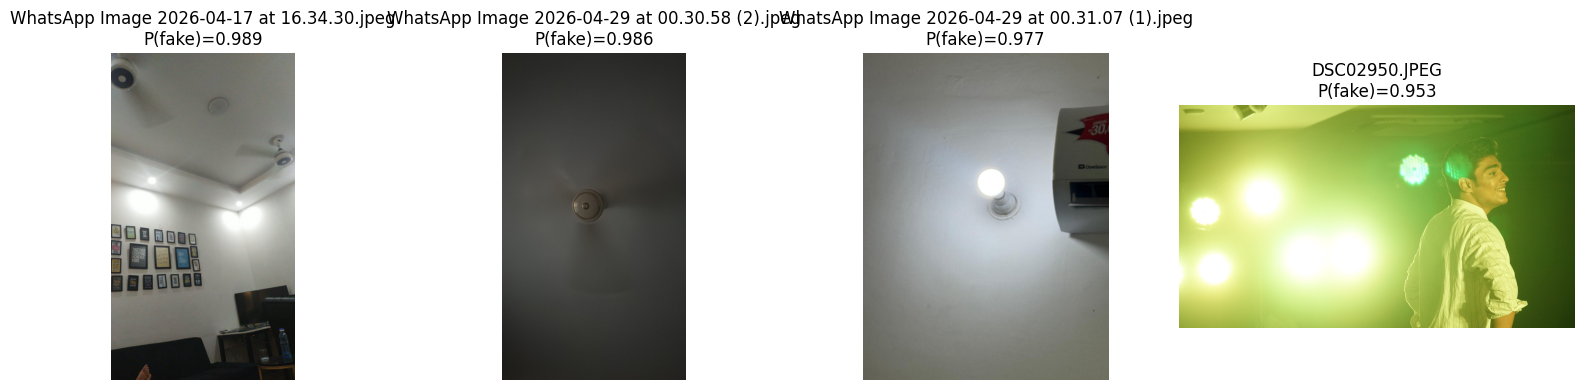

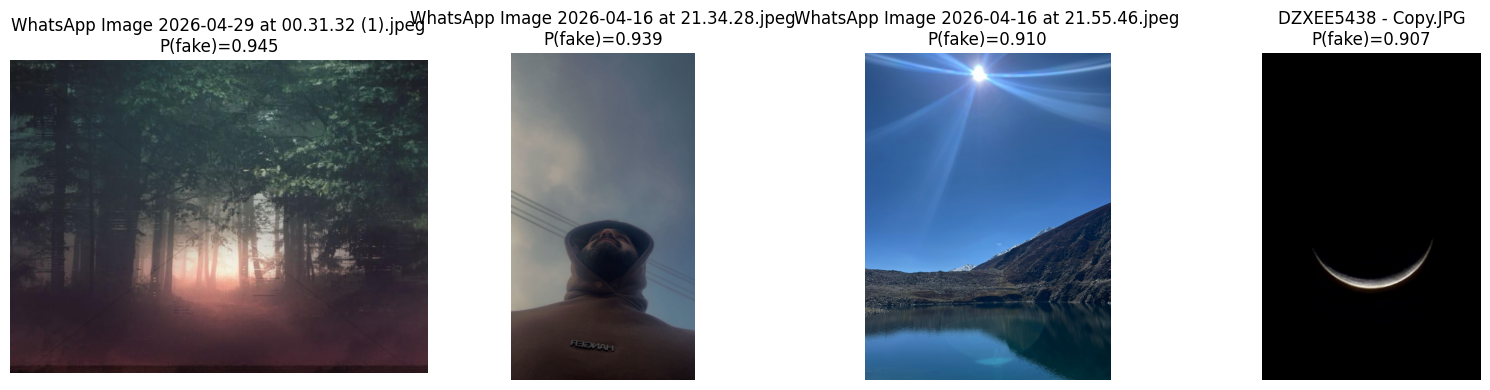

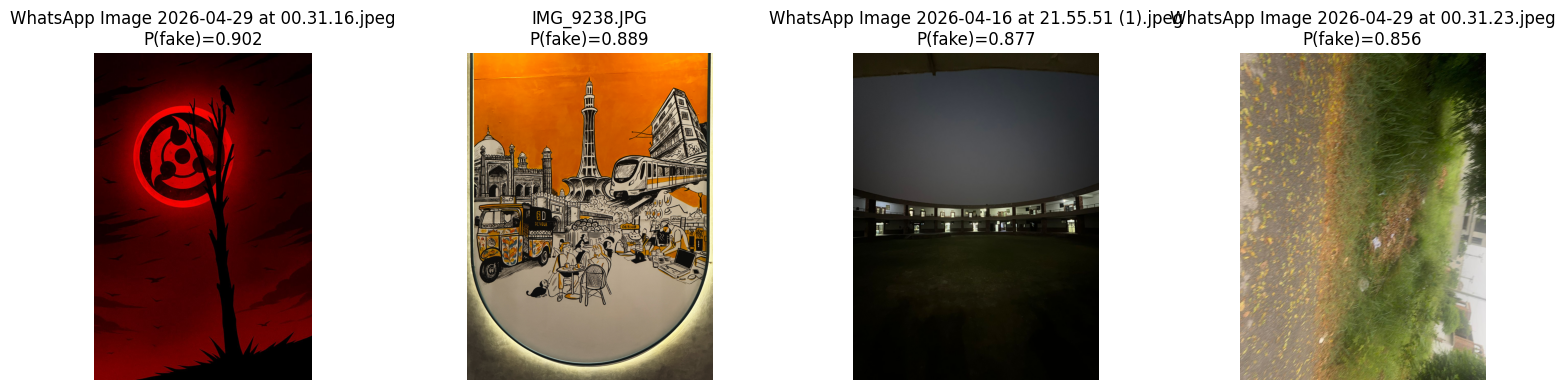

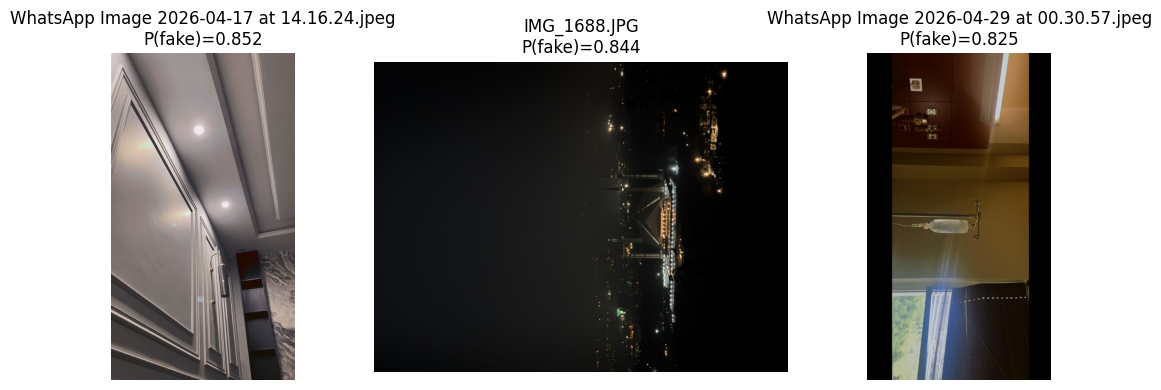

In [40]:
# ============================================================
# VISUALIZE MOST CONFIDENT FALSE POSITIVES
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

N_SHOW = 20

false_positive_df = phone_results_df[
    phone_results_df["predicted_label"] == "fake"
].head(N_SHOW)

print(
    "False positives available:",
    len(
        phone_results_df[
            phone_results_df["predicted_label"]
            == "fake"
        ]
    ),
)

if len(false_positive_df) == 0:
    print(
        "Excellent: no phone images were "
        "classified as fake."
    )
else:
    for start in range(
        0,
        len(false_positive_df),
        4,
    ):
        group = false_positive_df.iloc[
            start:start + 4
        ]

        fig, axes = plt.subplots(
            1,
            len(group),
            figsize=(4 * len(group), 4),
        )

        if len(group) == 1:
            axes = [axes]

        for axis, (_, row) in zip(
            axes,
            group.iterrows(),
        ):
            try:
                image = Image.open(
                    row["path"]
                ).convert("RGB")

                axis.imshow(image)

                axis.set_title(
                    f"{row['filename']}\n"
                    f"P(fake)="
                    f"{row['fake_probability']:.3f}"
                )

                axis.axis("off")

            except Exception as error:
                axis.set_title(
                    f"Load error:\n{error}"
                )
                axis.axis("off")

        plt.tight_layout()
        plt.show()

In [46]:
# ============================================================
# VERIFY LINEAR-PROBE EVALUATION REQUIREMENTS
# ============================================================

required_variables = [
    "frozen_backbone",
    "probe",
    "feature_mean",
    "feature_std",
    "PROBE_THRESHOLD",
    "SpatialDataset",
    "test_refs",
    "celeb_refs",
    "DEVICE",
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + "\n\nRun the spatial dataset setup, checkpoint loading, "
          "and linear-probe training cells first."
    )

print("All required variables are available.")
print(f"Probe threshold: {PROBE_THRESHOLD:.4f}")

All required variables are available.
Probe threshold: 0.8250


In [47]:
# ============================================================
# BUILD FULL FF++ TEST AND CELEBDF LOADERS
# ============================================================

from torch.utils.data import DataLoader
from collections import Counter

EVAL_EMBED_BATCH_SIZE = 64
PROBE_INFERENCE_BATCH_SIZE = 256

ff_test_ds = SpatialDataset(
    test_refs,
    train=False,
)

celeb_test_ds = SpatialDataset(
    celeb_refs,
    train=False,
)

ff_test_loader = DataLoader(
    ff_test_ds,
    batch_size=EVAL_EMBED_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

celeb_test_loader = DataLoader(
    celeb_test_ds,
    batch_size=EVAL_EMBED_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print("FF++ test images:", len(ff_test_ds))
print("CelebDF images:  ", len(celeb_test_ds))

print("\nFF++ label distribution:")
print(Counter(int(ref.label) for ref in test_refs))

print("\nCelebDF label distribution:")
print(Counter(int(ref.label) for ref in celeb_refs))

FF++ test images: 26276
CelebDF images:   30000

FF++ label distribution:
Counter({1: 22332, 0: 3944})

CelebDF label distribution:
Counter({1: 20000, 0: 10000})


In [48]:
# ============================================================
# SAMPLE REFERENCE HELPERS
# ============================================================

def get_reference_path(ref):
    if hasattr(ref, "path"):
        return str(ref.path)

    if hasattr(ref, "image_path"):
        return str(ref.image_path)

    raise AttributeError(
        "Sample reference has neither 'path' nor 'image_path'."
    )


def get_reference_source(ref):
    if hasattr(ref, "source"):
        return str(ref.source)

    return "unknown_source"


def get_reference_label(ref):
    if not hasattr(ref, "label"):
        raise AttributeError(
            "Sample reference has no 'label' attribute."
        )

    return int(ref.label)

In [49]:
# ============================================================
# EXTRACT FROZEN BACKBONE EMBEDDINGS
# ============================================================

import numpy as np
import torch
from tqdm.auto import tqdm

@torch.inference_mode()
def extract_evaluation_embeddings(
    backbone,
    loader,
    refs,
    description,
):
    backbone.eval()

    all_features = []
    all_labels = []

    for batch in tqdm(loader, desc=description):
        images = batch[0].to(
            DEVICE,
            non_blocking=True,
        )

        labels = torch.as_tensor(
            batch[1]
        ).long()

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            features = backbone(images)

        all_features.append(
            features.float().cpu()
        )

        all_labels.append(
            labels.cpu()
        )

    features = torch.cat(
        all_features,
        dim=0,
    )

    labels = torch.cat(
        all_labels,
        dim=0,
    )

    sources = [
        get_reference_source(ref)
        for ref in refs
    ]

    paths = [
        get_reference_path(ref)
        for ref in refs
    ]

    if len(features) != len(refs):
        raise RuntimeError(
            f"Extracted {len(features)} embeddings "
            f"for {len(refs)} references."
        )

    return features, labels, sources, paths


X_ff_test, y_ff_test, ff_sources, ff_paths = (
    extract_evaluation_embeddings(
        frozen_backbone,
        ff_test_loader,
        test_refs,
        "Extracting FF++ test embeddings",
    )
)

X_celeb, y_celeb, celeb_sources, celeb_paths = (
    extract_evaluation_embeddings(
        frozen_backbone,
        celeb_test_loader,
        celeb_refs,
        "Extracting CelebDF embeddings",
    )
)

print("\nEmbedding shapes:")
print("FF++:   ", X_ff_test.shape)
print("CelebDF:", X_celeb.shape)

Extracting FF++ test embeddings:   0%|          | 0/411 [00:00<?, ?it/s]

Extracting CelebDF embeddings:   0%|          | 0/469 [00:00<?, ?it/s]


Embedding shapes:
FF++:    torch.Size([26276, 1536])
CelebDF: torch.Size([30000, 1536])


In [50]:
# ============================================================
# STANDARDIZE USING PROBE TRAINING STATISTICS
# ============================================================

X_ff_test_std = (
    X_ff_test - feature_mean
) / feature_std

X_celeb_std = (
    X_celeb - feature_mean
) / feature_std

print("Evaluation embeddings standardized.")

Evaluation embeddings standardized.


In [51]:
# ============================================================
# LINEAR-PROBE INFERENCE
# ============================================================

@torch.inference_mode()
def get_linear_probe_probabilities(
    probe_model,
    features,
    batch_size=256,
):
    probe_model.eval()

    all_probabilities = []

    for start in range(
        0,
        len(features),
        batch_size,
    ):
        batch = features[
            start:start + batch_size
        ].to(DEVICE)

        logits = probe_model(batch)

        probabilities = torch.sigmoid(logits)

        all_probabilities.extend(
            probabilities.cpu().numpy().tolist()
        )

    return np.asarray(
        all_probabilities,
        dtype=np.float32,
    )


ff_probs = get_linear_probe_probabilities(
    probe,
    X_ff_test_std,
    batch_size=PROBE_INFERENCE_BATCH_SIZE,
)

celeb_probs = get_linear_probe_probabilities(
    probe,
    X_celeb_std,
    batch_size=PROBE_INFERENCE_BATCH_SIZE,
)

ff_preds = (
    ff_probs >= PROBE_THRESHOLD
).astype(int)

celeb_preds = (
    celeb_probs >= PROBE_THRESHOLD
).astype(int)

print("Predictions generated.")

Predictions generated.


In [52]:
# ============================================================
# METRIC HELPERS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
)

def calculate_binary_metrics(
    labels,
    predictions,
    probabilities,
):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)

    result = {
        "n": len(labels),
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "real_f1": f1_score(
            labels,
            predictions,
            pos_label=0,
            zero_division=0,
        ),
        "fake_f1": f1_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),
        "real_precision": precision_score(
            labels,
            predictions,
            pos_label=0,
            zero_division=0,
        ),
        "fake_precision": precision_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),
        "real_recall": recall_score(
            labels,
            predictions,
            pos_label=0,
            zero_division=0,
        ),
        "fake_recall": recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        ),
        "mean_fake_probability": float(
            probabilities.mean()
        ),
    }

    if len(np.unique(labels)) == 2:
        result["auc"] = roc_auc_score(
            labels,
            probabilities,
        )
    else:
        result["auc"] = np.nan

    return result


def print_binary_results(
    title,
    labels,
    predictions,
    probabilities,
):
    metrics = calculate_binary_metrics(
        labels,
        predictions,
        probabilities,
    )

    print("\n" + "=" * 76)
    print(title)
    print("=" * 76)

    print(f"Threshold             : {PROBE_THRESHOLD:.4f}")
    print(f"Samples               : {metrics['n']:,}")
    print(f"Accuracy              : {metrics['accuracy']:.4f}")
    print(f"Macro F1              : {metrics['macro_f1']:.4f}")
    print(f"Real F1               : {metrics['real_f1']:.4f}")
    print(f"Fake F1               : {metrics['fake_f1']:.4f}")
    print(f"Real precision        : {metrics['real_precision']:.4f}")
    print(f"Real recall           : {metrics['real_recall']:.4f}")
    print(f"Fake precision        : {metrics['fake_precision']:.4f}")
    print(f"Fake recall           : {metrics['fake_recall']:.4f}")
    print(f"ROC-AUC               : {metrics['auc']:.4f}")
    print(
        f"Mean fake probability : "
        f"{metrics['mean_fake_probability']:.4f}"
    )

    print(
        "\nConfusion matrix "
        "[[real→real, real→fake], "
        "[fake→real, fake→fake]]:"
    )

    print(
        confusion_matrix(
            labels,
            predictions,
            labels=[0, 1],
        )
    )

    return metrics

In [53]:
# ============================================================
# FULL EVALUATION
# ============================================================

ff_labels = y_ff_test.numpy()
celeb_labels = y_celeb.numpy()

ff_metrics = print_binary_results(
    "LINEAR PROBE — FULL FF++ TEST",
    ff_labels,
    ff_preds,
    ff_probs,
)

celeb_metrics = print_binary_results(
    "LINEAR PROBE — CELEBDF CROSS-DATASET",
    celeb_labels,
    celeb_preds,
    celeb_probs,
)


LINEAR PROBE — FULL FF++ TEST
Threshold             : 0.8250
Samples               : 26,276
Accuracy              : 0.9353
Macro F1              : 0.8856
Real F1               : 0.8101
Fake F1               : 0.9610
Real precision        : 0.7236
Real recall           : 0.9201
Fake precision        : 0.9852
Fake recall           : 0.9379
ROC-AUC               : 0.9781
Mean fake probability : 0.8296

Confusion matrix [[real→real, real→fake], [fake→real, fake→fake]]:
[[ 3629   315]
 [ 1386 20946]]

LINEAR PROBE — CELEBDF CROSS-DATASET
Threshold             : 0.8250
Samples               : 30,000
Accuracy              : 0.5974
Macro F1              : 0.5970
Real F1               : 0.5833
Fake F1               : 0.6106
Real precision        : 0.4453
Real recall           : 0.8453
Fake precision        : 0.8596
Fake recall           : 0.4735
ROC-AUC               : 0.7729
Mean fake probability : 0.5068

Confusion matrix [[real→real, real→fake], [fake→real, fake→fake]]:
[[ 8453  1547]
 [105

In [54]:
# ============================================================
# FF++ PER-MANIPULATION RESULTS
# ============================================================

import pandas as pd

ff_source_array = np.asarray(ff_sources)

per_source_rows = []

for source in sorted(set(ff_sources)):
    mask = ff_source_array == source

    labels = ff_labels[mask]
    predictions = ff_preds[mask]
    probabilities = ff_probs[mask]

    unique_labels = np.unique(labels)

    row = {
        "source": source,
        "n": int(mask.sum()),
        "true_class": (
            "real"
            if len(unique_labels) == 1
            and unique_labels[0] == 0
            else "fake"
            if len(unique_labels) == 1
            and unique_labels[0] == 1
            else "mixed"
        ),
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "mean_fake_probability": float(
            probabilities.mean()
        ),
    }

    if len(unique_labels) == 1:
        true_label = int(unique_labels[0])

        row["true_class_recall"] = recall_score(
            labels,
            predictions,
            pos_label=true_label,
            zero_division=0,
        )
    else:
        row["true_class_recall"] = np.nan

    per_source_rows.append(row)


ff_per_source_df = pd.DataFrame(
    per_source_rows
).sort_values(
    by="accuracy",
    ascending=True,
).reset_index(drop=True)

display(ff_per_source_df)

,source,n,true_class,accuracy,mean_fake_probability,true_class_recall
0,ff_NeuralTextures,3744,fake,0.866453,0.903410,0.866453
1,ff_Real,3944,real,0.920132,0.127992,0.920132
2,ff_FaceSwap,4044,fake,0.939664,0.951910,0.939664
3,ff_FaceShifter,3715,fake,0.941588,0.957447,0.941588
4,ff_DeepFakeDetection,3000,fake,0.950333,0.965569,0.950333
5,ff_Face2Face,3954,fake,0.958270,0.966665,0.958270
6,ff_Deepfakes,3875,fake,0.971355,0.976758,0.971355


In [55]:
# ============================================================
# CELEBDF SOURCE BREAKDOWN
# ============================================================

celeb_source_array = np.asarray(celeb_sources)

celeb_source_rows = []

for source in sorted(set(celeb_sources)):
    mask = celeb_source_array == source

    labels = celeb_labels[mask]
    predictions = celeb_preds[mask]
    probabilities = celeb_probs[mask]

    unique_labels = np.unique(labels)

    row = {
        "source": source,
        "n": int(mask.sum()),
        "true_class": (
            "real"
            if len(unique_labels) == 1
            and unique_labels[0] == 0
            else "fake"
            if len(unique_labels) == 1
            and unique_labels[0] == 1
            else "mixed"
        ),
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "mean_fake_probability": float(
            probabilities.mean()
        ),
    }

    if len(unique_labels) == 1:
        true_label = int(unique_labels[0])

        row["true_class_recall"] = recall_score(
            labels,
            predictions,
            pos_label=true_label,
            zero_division=0,
        )
    else:
        row["true_class_recall"] = np.nan

    celeb_source_rows.append(row)


celeb_per_source_df = pd.DataFrame(
    celeb_source_rows
).sort_values(
    by="accuracy",
    ascending=True,
).reset_index(drop=True)

display(celeb_per_source_df)

,source,n,true_class,accuracy,mean_fake_probability,true_class_recall
0,celebdf_fake,20000,fake,0.4735,0.626168,0.4735
1,celebdf_real,10000,real,0.8453,0.268131,0.8453


In [56]:
# ============================================================
# ORIGINAL VS LINEAR-PROBE COMPARISON
# ============================================================

comparison_df = pd.DataFrame([
    {
        "model": "Original spatial head",
        "dataset": "FF++ Test",
        "accuracy": 0.9555,
        "macro_f1": 0.9116,
        "real_f1": 0.8493,
        "fake_f1": 0.9739,
        "auc": np.nan,
    },
    {
        "model": "Linear probe",
        "dataset": "FF++ Test",
        "accuracy": ff_metrics["accuracy"],
        "macro_f1": ff_metrics["macro_f1"],
        "real_f1": ff_metrics["real_f1"],
        "fake_f1": ff_metrics["fake_f1"],
        "auc": ff_metrics["auc"],
    },
    {
        "model": "Original spatial head",
        "dataset": "CelebDF",
        "accuracy": 0.7513,
        "macro_f1": 0.6918,
        "real_f1": 0.5564,
        "fake_f1": 0.8272,
        "auc": 0.7641,
    },
    {
        "model": "Linear probe",
        "dataset": "CelebDF",
        "accuracy": celeb_metrics["accuracy"],
        "macro_f1": celeb_metrics["macro_f1"],
        "real_f1": celeb_metrics["real_f1"],
        "fake_f1": celeb_metrics["fake_f1"],
        "auc": celeb_metrics["auc"],
    },
])

display(comparison_df)

,model,dataset,accuracy,macro_f1,real_f1,fake_f1,auc
0,Original spatial head,FF++ Test,0.955500,0.911600,0.849300,0.973900,NaN
1,Linear probe,FF++ Test,0.935264,0.885558,0.810135,0.960980,0.978105
2,Original spatial head,CelebDF,0.751300,0.691800,0.556400,0.827200,0.764100
3,Linear probe,CelebDF,0.597433,0.596970,0.583307,0.610633,0.772906


In [ ]:
# ============================================================
# SAVE DETAILED EVALUATION RESULTS
# ============================================================

ff_results_df = pd.DataFrame({
    "path": ff_paths,
    "source": ff_sources,
    "true_label": np.where(
        ff_labels == 1,
        "fake",
        "real",
    ),
    "fake_probability": ff_probs,
    "predicted_label": np.where(
        ff_preds == 1,
        "fake",
        "real",
    ),
    "correct": ff_preds == ff_labels,
})

celeb_results_df = pd.DataFrame({
    "path": celeb_paths,
    "source": celeb_sources,
    "true_label": np.where(
        celeb_labels == 1,
        "fake",
        "real",
    ),
    "fake_probability": celeb_probs,
    "predicted_label": np.where(
        celeb_preds == 1,
        "fake",
        "real",
    ),
    "correct": celeb_preds == celeb_labels,
})

ff_output_path = (
    "/kaggle/working/"
    "linear_probe_ffpp_test_results.csv"
)

celeb_output_path = (
    "/kaggle/working/"
    "linear_probe_celebdf_results.csv"
)

ff_results_df.to_csv(
    ff_output_path,
    index=False,
)

celeb_results_df.to_csv(
    celeb_output_path,
    index=False,
)

print("Saved:", ff_output_path)
print("Saved:", celeb_output_path)